# Documentation

This file is to analyze the MJO in data from the CAMulator CAM6 emulator (https://arxiv.org/abs/2504.06007)

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

print("Loading imports...")
# CAMulator analysis config file
from config import *

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# File management
import glob
import os
import sys
from datetime import datetime, timedelta
import copy
import cftime

# Data anaylsis
import numpy as np
import scipy
import xarray as xr
# import xeofs
xr.set_options(keep_attrs=True)
import scipy.signal as signal
from scipy.stats import t
from geocat.comp import interpolation
import glob

# Plotting
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LongitudeLocator, LatitudeLocator

plt.rcParams['mathtext.fontset'] = 'dejavusans'

# Auxiliary functions
sys.path.insert(0, "/glade/u/home/sressel/thesis-work/python/auxiliary_functions/")
# from plotting_functions import *
# from load_aquaplanet_data import *
from processing_functions import *
from standardize_data import standardize_data
from modified_colormap import modified_colormap
from bmh_colors import bmh_colors
from one_two_one_filter import one_two_one_filter
from tick_labeller import tick_labeller
from rounding_functions import round_out
from add_cyclic_xarray import add_cyclic_xarray

print("Imports loaded")

Loading imports...
Imports loaded


# Process data

## Load CAMulator Data

In [2]:
print("Loading data...", end="")
future_warming_directory = "/glade/derecho/scratch/wchapman/CREDIT/new_pxshf/Post_003steps/runfilt_future_00091/2015-01-01T00Z/1D/"

files_list = sorted(glob.glob(f"{data_directory}/averaged_UVTQtotPSPRECTTREFHTTAUXTAUY_*_1D.nc"))
warmed_files_list = sorted(glob.glob(f"{future_warming_directory}/averaged_UVTQtotPSPRECTTREFHTTAUXTAUY_*_1D.nc"))

# loaded_data = xr.open_mfdataset(files_list)
# loaded_warmed_data = xr.open_mfdataset(warmed_files_list)
loaded_data = xr.open_mfdataset(warmed_files_list)
print(rf"{'✔':>1}")

Loading data...✔


## Interpolate to pressure levels

In [3]:
non_timed_data =  xr.open_dataset(
    rf"/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_-4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_-4K_3h_20y_new2.cam.h1.0001-02-16-43200.nc"
)
non_timed_data = non_timed_data.rename({'lev':'level', 'lat':'latitude', 'lon':'longitude'})
interpolated_pressure_level_data = {}

print(f"{'Interpolating...':^{str_width}}")
print(f"{'='*str_width}")
multi_level_variables = (data_var for data_var in loaded_data.data_vars if 'level' in loaded_data[data_var].coords)
for index, variable_name in enumerate(multi_level_variables):
    print(f'{f"({index+1}) {variable_name}...":<{str_width-1}}', end="")
    interpolated_pressure_level_data[variable_name] = interpolation.interp_hybrid_to_pressure(
        loaded_data[variable_name],
        loaded_data['PS'],
        non_timed_data['hyam'],
        non_timed_data['hybm'],
        new_levels=100*np.array(
            [25,   50,   75,  100,  125,  150,  175,  200,  225,  250,  275,  300, 325,  350,  375,  400,  425,  450,  475,  500,  525,  550,  575,  600, 625,  650,  675,  700,  725,  750,  775,  800,  825,  850,  875,  900, 925,  950,  975, 1000]
        )
    )
    interpolated_pressure_level_data[variable_name]['plev'] = interpolated_pressure_level_data[variable_name].plev/100
    print(rf"{'✔':>1}")

variable_data = {}
variable_data['Zonal Wind'] = interpolated_pressure_level_data['U']
variable_data['Zonal Wind'].name = 'Zonal Wind'
variable_data['Zonal Wind'].attrs = {'units':r'm s$^{-1}$', 'long_name':'zonal_wind', 'short_name':'U'}
variable_data['Meridional Wind'] = interpolated_pressure_level_data['V']
variable_data['Meridional Wind'].name = 'Meridional Wind'
variable_data['Meridional Wind'].attrs = {'units':r'm s$^{-1}$', 'long_name':'meridional_wind', 'short_name':'V'}
variable_data['Temperature'] = interpolated_pressure_level_data['T']
variable_data['Temperature'].name = 'Temperature'
variable_data['Temperature'].attrs = {'units':r'K', 'long_name':'temperature', 'short_name':'T'}
variable_data['Specific Total Water'] = interpolated_pressure_level_data['Qtot']
variable_data['Specific Total Water'].name = 'Specific Total Water'
variable_data['Specific Total Water'].attrs = {'units':r'kg kg$^{-1}$', 'long_name':'specific_total_water', 'short_name':'Qtot'}
variable_data['Precipitation'] = 1000*loaded_data['PRECT']
variable_data['Precipitation'].name = 'Precipitation'
variable_data['Precipitation'].attrs = {'units':r'mm day$^{-1}$', 'long_name':'precipitation', 'short_name':'PRECT'}
print(f"{'='*str_width}")
print("Finished")

            Interpolating...            
(1) U...                               ✔
(2) V...                               ✔
(3) T...                               ✔
(4) Qtot...                            ✔
Finished


## Subset Data

In [9]:
# time_bounds = slice(
#     '1980-01-01T00:00:00.000000000',
#     '2010-12-31T00:00:00.000000000',
# )
time_bounds = slice(
    '2015-01-01T00:00:00.000000000',
    '2044-12-31T00:00:00.000000000',
)
lat_bounds = slice(-30, 30)

variables_subset = {}
for index, (name, data) in enumerate(variable_data.items()):
    print(f'{f"({index+1}/{len(variable_data)}) {name}...":<{str_width-1}}', end="")
    variables_subset[name] = data.sel(
        time=time_bounds,
        latitude=lat_bounds
    )
    variables_subset[name].attrs = data.attrs
    print(rf"{'✔':>1}")

print(f"{'='*str_width}")
print("Finished")

(1/5) Zonal Wind...                    ✔
(2/5) Meridional Wind...               ✔
(3/5) Temperature...                   ✔
(4/5) Specific Total Water...          ✔
(5/5) Precipitation...                 ✔
Finished


## Detrend Data

In [49]:
print("Detrending data")
variables_detrended = {}
# for index, (name, data) in enumerate(variables_subset.items()):
variables_to_detrend = (variables_subset[var] for var in variables_subset.keys() if var == 'Precipitation')
for index, data in enumerate(variables_to_detrend):
    print(f'{f"({index+1}/{len(list(variables_to_detrend))}) {name}...":<{str_width-1}}', end="")
    variables_detrended[name] = xr.zeros_like((data))
    variables_detrended[name][:] = signal.detrend(
            (data - data.mean(dim="time")).values,
            axis=0,
            type='linear',
        )
    variables_detrended[name].attrs = data.attrs
    print(rf"{'✔':>1}")

print(f"{'='*str_width}")
print("Finished")

Detrending data
(1/5) Precipitation...                 ✔
Finished


## Intraseasonally Filter Data

In [10]:
period_bounds = slice(100, 20)

variables_filtered = {}

print(f"{f'Filtering variables':^{str_width}}")
print(f"{'='*str_width}")
variables_to_filter = [variables_subset[var] for var in variables_subset.keys() if var == 'Precipitation']
for index, data in enumerate(variables_to_filter):
    variable_name = data.name
    print(f"{f'({index+1}/{len(list(variables_to_filter))}) {variable_name}...':<{str_width-1}}", end="")

    variables_filtered[variable_name] = time_filter_data(
        data,
        period_bounds
    )
    variables_filtered[variable_name].attrs = data.attrs

    print(rf"{'✔':>1}")
print(f"{'='*str_width}")

print(f"{'='*str_width}")
print("Finished")

          Filtering variables           
(1/1) Precipitation...                 ✔
Finished


# Analyze Data

## Plot Climatology

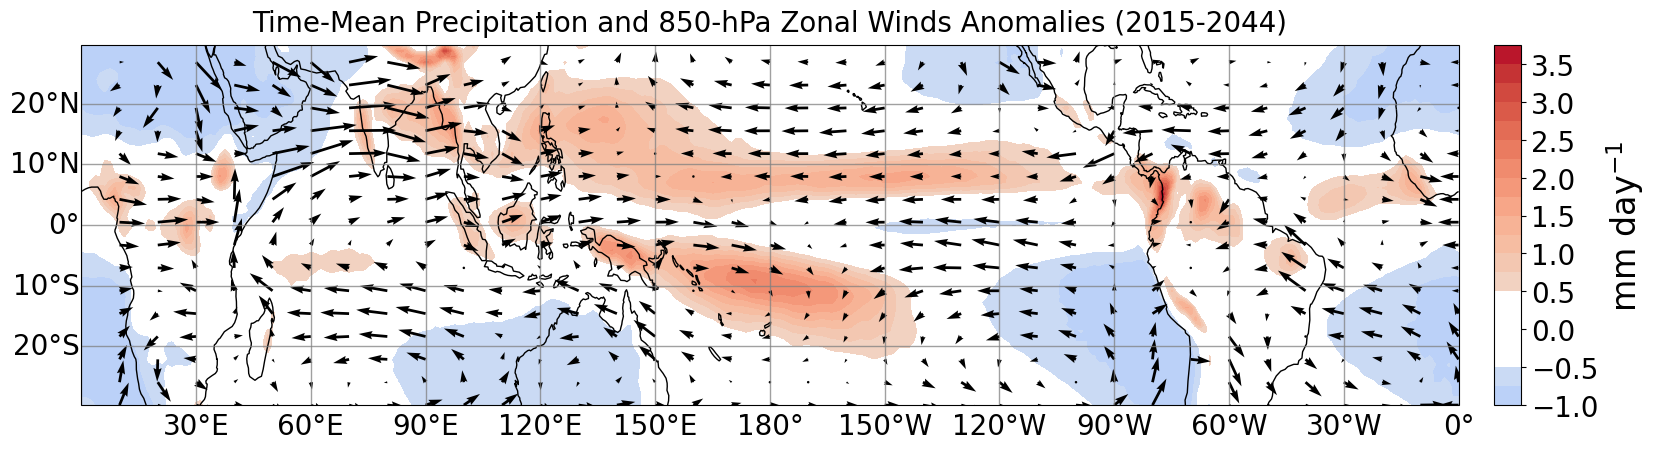

In [108]:
plt.style.use('default')
plt.rcParams.update({'font.size':24})
cmap_modified = mjo.modified_colormap('coolwarm', 'white', 0.1, 0.1)
# cmap_modified = 'BrBG'
coastline_width = 1

plev_to_plot = 850
reload_data = True
if 'precipitation_anomalies' not in locals() or reload_data:
    precipitation_anomalies = standardize_data(
        variables_subset['Precipitation'],
        dim=['time', 'latitude', 'longitude'],
        unit_variance=False
    ).compute()
    zonal_wind_anomalies = standardize_data(
        variables_subset['Zonal Wind'].sel(plev=plev_to_plot),
        dim=['time', 'latitude', 'longitude'],
        unit_variance=False
    ).compute()
    meridional_wind_anomalies = standardize_data(
        variables_subset['Meridional Wind'].sel(plev=plev_to_plot),
        dim=['time', 'latitude', 'longitude'],
        unit_variance=False
    ).compute()

    time_mean_precipitation_anomalies = precipitation_anomalies.mean(dim='time')
    time_mean_zonal_wind_anomalies = zonal_wind_anomalies.mean(dim='time')
    time_mean_meridional_wind_anomalies = meridional_wind_anomalies.mean(dim='time')

gs = GridSpec(1, 2, width_ratios=(1, 0.02))
gs.update(top=.95, bottom=0.05, left=0.05, right=.95, hspace=0, wspace=0.05)
f = plt.figure(figsize=(16,4))

ax = f.add_subplot(gs[0], projection=ccrs.PlateCarree(central_longitude=-180))
cb_ax = f.add_subplot(gs[1])

# Moisture Tendency
ax.set_title(
    (f"Time-Mean Precipitation and {plev_to_plot}-hPa Zonal Winds Anomalies "
    f"({variables_subset['Zonal Wind']['time'].dt.year[0].values}-{variables_subset['Zonal Wind']['time'].dt.year[-1].values})"),
    fontsize=20,
    pad=10
)

# Add cyclic point
cdata, clon = cutil.add_cyclic_point(
    time_mean_precipitation_anomalies,
    coord=precipitation_anomalies.longitude
)

im = ax.contourf(
    clon,
    precipitation_anomalies.latitude,
    cdata,
    transform=ccrs.PlateCarree(),
    # cmap='RdYlBu_r',
    cmap=cmap_modified,
    norm=mcolors.CenteredNorm(),
    levels=21
)
cbar = f.colorbar(im, cax=cb_ax)
cbar.ax.tick_params(labelsize=20)
# cbar.set_label(r'W m$^{-2}$')
cbar.set_label(r'mm day$^{-1}$')

arrow_spacing = 4
ax.quiver(
    zonal_wind_anomalies.longitude[::2*arrow_spacing],
    zonal_wind_anomalies.latitude[::arrow_spacing],
    time_mean_zonal_wind_anomalies.values[::arrow_spacing, ::2*arrow_spacing],
    time_mean_meridional_wind_anomalies.values[::arrow_spacing, ::2*arrow_spacing],
    width=0.002,
    scale=250,
    transform=ccrs.PlateCarree()
)

ax.set_aspect('auto')
ax.set_xlabel('')
ax.add_feature(cf.COASTLINE, lw=coastline_width)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=1,
    color="gray",
    alpha=0.75,
    linestyle="-",
    zorder=15
)
gl.right_labels = False
gl.top_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180,180,30))
# gl.xlocator = LongitudeLocator(30)
gl.xformatter = LongitudeFormatter()
gl.xlabel_style = {'fontsize':20}
gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
gl.yformatter = LatitudeFormatter()
gl.ylabel_style = {'fontsize':20}

plt.show()

In [201]:
underline = "\033[4m"
reset = "\033[0m"

save_regressed_variables = False
reference_variable = 'Precipitation'
# reference_variable = 'Lower Level Moisture'
data_type = 'regressed'

# Initialize the dictionary to hold the regressed values
multi_experiment_variables_regressed = {}

# # Identify the location of the reference time series
reference_latitude = (
    multi_experiment_variables_mjo_filtered['Precipitation']
).var(dim='time').mean(dim='lon').idxmax(dim='lat')
reference_longitude = 180*xr.ones_like(reference_latitude)

reference_latitude = xr.zeros_like(reference_latitude)
reference_longitude = 180*xr.ones_like(reference_latitude)

# selected_data = [
#     ds.sel(
#         lon=reference_longitude.sel(experiment=experiment),
#         lat=reference_latitude.sel(experiment=experiment),
#         method="nearest"
#     )
#     for experiment, ds in zip(experiments_list, multi_experiment_variables_mjo_filtered[reference_variable])
#     # for experiment, ds in zip(experiments_list, mjo_filtered_moisture.sel(plev=slice(100,975)).integrate('plev'))
# ]

# # Concatenate along the 'experiment' dimension
# reference_timeseries = xr.concat(selected_data, dim="experiment")
# reference_longitude = 180
# reference_latitude = 0
reference_timeseries = multi_experiment_variables_mjo_filtered[reference_variable].sel(lat=0, lon=180, method='nearest')
# longitude_bounds = (175, 185)
# latitude_bounds = (-5, 5)
# reference_timeseries = multi_experiment_variables_mjo_filtered[reference_variable].sel(
#         lat=slice(*latitude_bounds),
#         lon=slice(*longitude_bounds)
# ).mean(dim=['lat', 'lon'])
standardized_reference_timeseries = standardize_data(reference_timeseries, unit_variance=True, dim='time')

N = len(standardized_reference_timeseries.time)
t_critical = t.ppf(0.95, df=N-2)

significant_regression_indices = {}

print(f"{'Regressions':^{str_width}}")
print(f"{f'Regression Variable: {reference_variable}':^{str_width}}")
print(f"{'='*str_width}")

# Take a meridional mean over the specified domain
meridional_mean_data = {}
for variable_data in [
    # multi_experiment_variables_subset['Meridional Moisture Advection'],
    multi_experiment_variables_subset['Moisture'],
    multi_experiment_variables_subset['Zonal Wind'],
    multi_experiment_variables_subset['Vertical Wind']
]:

    meridional_mean_data[variable_data.name] = xr.concat(
        [
            variable_data.sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat'])
            for experiment in experiments_list
        ],
        dim=experiments_array
    )

meridional_mean_data['Precipitation'] = multi_experiment_variables_subset['Precipitation']
# for index, (variable_name, variable_data) in enumerate(multi_experiment_variables_subset.items()):
for index, (variable_name, variable_data) in enumerate(meridional_mean_data.items()):
# for index, (variable_name, variable_data) in enumerate(multi_experiment_budget_variables.items()):

    if not variable_name in variables_to_load:
        print(f"{variable_name} not in variables to load, skipping...")
        continue

    print(f'{f"({index+1}/{len(meridional_mean_data)}) {variable_name}...":<{str_width-1}}', end="")
    # print(f'{f"({index+1}/{len(multi_experiment_variables_subset)}) {variable_name}...":<{str_width-1}}', end="")
    # print(f'{f"({index+1}/{len(multi_experiment_budget_variables)}) {variable_name}...":<{str_width-1}}', end="")

    # Remove the time mean of the variables to be regressed
    variable_data_anomalies = standardize_data(variable_data, unit_variance=False, dim='time')

    # Regress the variable anomalies onto the reference timeseries
    multi_experiment_variables_regressed[variable_name] = xr.dot(
        standardized_reference_timeseries,
        variable_data_anomalies,
        dim='time'
    ) / len(standardized_reference_timeseries.time)
    multi_experiment_variables_regressed[variable_name].attrs = variable_data_anomalies.attrs
    multi_experiment_variables_regressed[variable_name].name = variable_name

    # Calculate the statstical significance of the regression coefficients
    predicted_value = multi_experiment_variables_regressed[variable_name] * standardized_reference_timeseries
    residual_sum_of_squares = ((variable_data_anomalies - predicted_value) ** 2).sum(dim='time')
    residual_variance = residual_sum_of_squares / (N - 2)
    standard_error_slope = np.sqrt(residual_variance / (N - 1))
    t_statistic = multi_experiment_variables_regressed[variable_name] / standard_error_slope
    significant_regression_indices[variable_name] = np.abs(t_statistic) > t_critical

    print(rf"{'✔':>1}")

print(f"{'-'*str_width}")

# print("Re-scaling regressed timeseries")
# rescaled_multi_experiment_variables_regressed = {}
# rescaled_multi_experiment_variables_regressed = copy.deepcopy(multi_experiment_variables_regressed)
# print(f"{'-'*str_width}")

# rescaling_constant = {}
# rescaling_constant['Outgoing Longwave Radiation'] = -40
# rescaling_constant['Precipitation'] = 15
# rescaling_constant['Upper Level Moisture'] = 10
# rescaling_constant['Lower Level Moisture'] = 10

# for index, (variable_name, variable_data) in enumerate(multi_experiment_variables_regressed.items()):
#     print(f'{f"({index+1}/{len(multi_experiment_variables_regressed)}) {variable_name}...":<{str_width-1}}', end="")

#     for ((experiment_index, experiment), latitude, longitude) in zip(enumerate(experiments_list), reference_latitude, reference_longitude):
#         # print(f'{f"{experiment}...":<{str_width-1}}', end="")
#         rescaling_factor = (
#             rescaling_constant[reference_variable]
#             / multi_experiment_variables_regressed[reference_variable].sel(experiment=experiment).sel(lat=latitude, lon=longitude, method='nearest')
#         )
#         rescaled_multi_experiment_variables_regressed[variable_name][experiment_index] = (
#             rescaling_factor.copy(deep=True)
#             * multi_experiment_variables_regressed[variable_name].sel(experiment=experiment)
#         )
#         rescaled_multi_experiment_variables_regressed[variable_name].attrs['rescaled'] = 'True'
#     print(rf"{'✔':>1}")
# print(f"{'-'*str_width}")

if save_regressed_variables:
    print(f"{'Saving regressed variables':^{str_width}}")
    print(f"{'='*str_width}")

    for index, (variable_name, variable_data) in enumerate(multi_experiment_variables_regressed.items()):
        print(f"{f'({index+1}/{len(multi_experiment_variables_regressed)}) {variable_name}...':<{str_width-1}}", end="")
        multi_experiment_variables_regressed[variable_name].name = variable_name
        significant_regression_indices[variable_name].name = variable_name

        filename = (
            f"{data_directory}/multi_experiment_variables_regressed/"
            + f"multi_experiment_{variable_name.lower().replace(' ', '_')}_"
            # + f"MJO-{rescaled_multi_experiment_variables_regressed[reference_variable].attrs['short_name']}.nc"
            + f"MJO-{multi_experiment_variables_mjo_filtered[reference_variable].attrs['short_name']}.nc"
        )
        combined_data = xr.Dataset(
            {
                f"{variable_name} - Coefficients": multi_experiment_variables_regressed[variable_name],
                f"{variable_name} - Significance": significant_regression_indices[variable_name]
            }
        )
        if os.path.exists(filename):
            # Prompt user for confirmation
            # response = input(f"\nFile '{filename}' already exists. Overwrite? (y/n): ").strip().lower()
            response = 'y'
            if response == 'y':
                os.remove(filename)  # Delete the existing file

                # combined_data["name"] = variable_data.name
                combined_data.to_netcdf(filename)  # Save the new file
                print(rf"{'✔ (overwritten)':>1}")
            else:
                print(rf"{'✘ (skipped)':>1}")
        else:
            combined_data.to_netcdf(filename)  # Save the new file
            print(rf"{'✔':>1}")
else:
    print(f"{'Not saving regressed variables':<{str_width}}")

print(f"{'='*str_width}")
print("Finished")

NameError: name 'multi_experiment_variables_mjo_filtered' is not defined

In [13]:
precipitation_aligned, z_aligned = xr.align(precipitation, z, join="override")
masked = precipitation_aligned.where(z_aligned == 0).fillna(0)

In [12]:
import glob
files = glob.glob("/glade/derecho/scratch/wchapman/CREDIT/new_pxshf/Post_003steps/runfilt_future_00091/2015-01-01T00Z/1D/*")
xr.open_dataset(files[0])

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 31, level: 32, latitude: 192, longitude: 288)
Coordinates:
  * level      (level) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * latitude   (latitude) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * longitude  (longitude) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time       (time) datetime64[ns] 248B 2037-10-01 2037-10-02 ... 2037-10-31
Data variables:
    U          (time, level, latitude, longitude) float64 439MB ...
    V          (time, level, latitude, longitude) float64 439MB ...
    T          (time, level, latitude, longitude) float64 439MB ...
    Qtot       (time, level, latitude, longitude) float64 439MB ...
    PS         (time, latitude, longitude) float64 14MB ...
    PRECT      (time, latitude, longitude) float64 14MB ...
    TREFHT     (time, latitude, longitude) float64 14MB ...
    TS         (time, latitude, longitude) float64 14MB ...
    TAUX       (time, latitude, longitude) float64 14MB ...
    TAUY       (time, latitude, longitude) float64 14MB ...

In [28]:
variables_detrended['Precipitation']

<xarray.DataArray 'PRECT' (time: 12410, lat: 192, lon: 288)> Size: 5GB
dask.array<setitem, shape=(12410, 192, 288), dtype=float64, chunksize=(31, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) datetime64[ns] 99kB 1981-01-01 1981-01-02 ... 2014-12-31
Attributes:
    file_id:  PRCP

In [226]:
variables_detrended['Precipitation']

<xarray.DataArray 'Precipitation' (time: 12410, latitude: 64, longitude: 288)> Size: 2GB
dask.array<setitem, shape=(12410, 64, 288), dtype=float64, chunksize=(31, 64, 288), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -29.69 -28.74 -27.8 ... 27.8 28.74 29.69
  * longitude  (longitude) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time       (time) datetime64[ns] 99kB 1981-01-01 1981-01-02 ... 2014-12-31
Attributes:
    units:       mm day$^{-1}$
    long_name:   precipitation
    short_name:  PRECT

## Space-Time Power Specta

In [51]:
from global_land_mask import globe

# Make a grid
lon_grid, lat_grid = np.meshgrid(variables_detrended['Precipitation'].longitude, variables_detrended['Precipitation'].latitude)

# Get whether the points are on land.
z = xr.zeros_like(variables_detrended['Precipitation'].isel(time=0, drop=True))
z[:] = globe.is_land(lat_grid, (variables_detrended['Precipitation'].longitude+180)%360-180)
z = z.rename({'latitude':'latitude', 'longitude':'longitude'})

xr.set_options(keep_attrs=True)
print(f"{'Space-Time Power Spectra':^{str_width}}")

max_latitude = 15
mask_land = True

recalculate_signal = True
plot_raw_spectrum = False
plot_background_spectrum = True
plot_signal_strength = True
save_plots = False
n_smooths = 15

# if 'symmetric_power_spectrum' not in locals():
symmetric_signal_fft = {}
asymmetric_signal_fft = {}
raw_symmetric_power = {}
raw_asymmetric_power = {}
background_spectrum = {}
symmetric_power_spectrum = {}
asymmetric_power_spectrum = {}

# Subset into segments in time (96 days, overlap 60 days)
segment_length = 192
# overlap = 192//2
# segment_length = 96
# overlap = 60
overlap = 96
window_width = 5

for index, variable in enumerate([
    variables_detrended['Precipitation'],
    # variables_detrended['Zonal Wind'].sel(plev=850),
]):

    variable_id = f"{variable.attrs['short_name']}{(str(variable.plev.values) if 'plev' in variable.coords else '')}"

    print(f"{'='*str_width}")
    print(f"{f'Variable: {variable_id}':^{str_width}}")
    print(f"{'-'*str_width}")

    # Calculate the frequency and zonal wavenumber axis coordinates
    frequency = np.arange(-segment_length / 2, segment_length / 2) * 1 / segment_length
    zonal_wavenumber = (
        np.arange(-len(variable.longitude) / 2, len(variable.longitude) / 2)
        * (1 / np.diff(variable.longitude)[0])
        / len(variable.longitude)
        * 360
    )

    symmetric_power_spectrum[variable_id] = []
    asymmetric_power_spectrum[variable_id] = []
    print(f"{f'→ Defining symmetric signals...':<{str_width-1}}", end="")

    variable_data = variables_detrended['Precipitation']

    variable_aligned, z_aligned = xr.align(variable_data, z, join="override")
    masked_variable = variable_aligned.where(z_aligned == 0).fillna(0)

    # Separate into symmetric/antisymmetric component
    symmetric_signal = xr.zeros_like(masked_variable.sel(latitude=slice(0, max_latitude)))
    asymmetric_signal = xr.zeros_like(masked_variable.sel(latitude=slice(0, max_latitude)))

    for latitude_index, latitude in enumerate(symmetric_signal.latitude):
        symmetric_signal[:, latitude_index, :] = (1 / 2) * (
            variable_data.sel(latitude=latitude, method="nearest")
            + variable_data.sel(latitude=-latitude, method="nearest")
        )
        asymmetric_signal[:, latitude_index, :] = -(1 / 2) * (
            variable_data.sel(latitude=latitude, method="nearest")
            - variable_data.sel(latitude=-latitude, method="nearest")
        )

    symmetric_signal = symmetric_signal.fillna(0)
    asymmetric_signal = asymmetric_signal.fillna(0)

    # Define the Hann window
    hann_window = np.concatenate(
        (
            np.hanning(2*window_width)[:window_width],
            np.ones(segment_length - window_width * 2),
            np.hanning(2*window_width)[::-1][window_width:],
        ),
        axis=0,
    )
    print(rf"{'✔':>1}")

    print(f"{f'→ Segmenting data...':<{str_width-1}}", end="")
    # Segment the data
    symmetric_signal_segmented = symmetric_signal.rolling(
        time=segment_length, center=False
    ).construct("day_in_segment").rename({'time': 'segment_index'})

    symmetric_signal_segmented = symmetric_signal_segmented[(segment_length - 1) :][
        :: (segment_length - overlap)
    ].transpose("segment_index", "day_in_segment", "latitude", "longitude")

    asymmetric_signal_segmented = asymmetric_signal.rolling(
        time=segment_length, center=False
    ).construct("day_in_segment").rename({'time': 'segment_index'})

    asymmetric_signal_segmented = asymmetric_signal_segmented[(segment_length - 1) :][
        :: (segment_length - overlap)
    ].transpose("segment_index", "day_in_segment", "latitude", "longitude")
    print(rf"{'✔':>1}")

    print(f"{f'→ Detrending data...':<{str_width-1}}", end="")
    # Detrend the data along the segmented axis
    symmetric_signal_detrended = xr.zeros_like((symmetric_signal_segmented))
    asymmetric_signal_detrended = xr.zeros_like((asymmetric_signal_segmented))
    symmetric_signal_detrended[:] = signal.detrend(symmetric_signal_segmented, axis=1)
    asymmetric_signal_detrended[:] = signal.detrend(asymmetric_signal_segmented, axis=1)
    print(rf"{'✔':>1}")

    print(f"{f'→ Windowing data...':<{str_width-1}}", end="")
    # Apply the Hann window to each segment
    symmetric_signal_windowed = xr.zeros_like((symmetric_signal_detrended))
    asymmetric_signal_windowed = xr.zeros_like((asymmetric_signal_detrended))
    symmetric_signal_windowed[:] = np.einsum(
        "j,ijkl->ijkl", hann_window, symmetric_signal_detrended
    )
    asymmetric_signal_windowed[:] = np.einsum(
        "j,ijkl->ijkl", hann_window, asymmetric_signal_detrended
    )
    print(rf"{'✔':>1}")

    print(f"{f'→ Fourier transforming data...':<{str_width-1}}", end="")
    # Fourier transform the data and calculate raw power
    symmetric_signal_fft[variable_id] = xr.DataArray(
        data=np.zeros_like((symmetric_signal_windowed)),
        dims=['segment_index', 'frequency', 'latitude', 'wavenumber'],
        coords={
            'segment_index': symmetric_signal_windowed.segment_index,
            'frequency': np.fft.fftshift(np.fft.fftfreq(len(symmetric_signal_windowed.day_in_segment), 1)),
            'latitude': symmetric_signal_windowed.latitude,
            'wavenumber': np.fft.fftshift(360*np.fft.fftfreq(len(symmetric_signal_windowed.longitude), np.diff(symmetric_signal_windowed.longitude)[0]))
        }
    )
    asymmetric_signal_fft[variable_id] = xr.DataArray(
        data=np.zeros_like((symmetric_signal_windowed)),
        dims=['segment_index', 'frequency', 'latitude', 'wavenumber'],
        coords={
            'segment_index': symmetric_signal_windowed.segment_index,
            'frequency': np.fft.fftshift(np.fft.fftfreq(len(symmetric_signal_windowed.day_in_segment), 1)),
            'latitude': symmetric_signal_windowed.latitude,
            'wavenumber': np.fft.fftshift(360*np.fft.fftfreq(len(symmetric_signal_windowed.longitude), np.diff(symmetric_signal_windowed.longitude)[0]))
        }
    )
    symmetric_signal_fft[variable_id][:] = (
        np.fft.fftshift(np.fft.fft2(symmetric_signal_windowed, axes=(1, 3)), axes=(1,3))
        / (len(variable.longitude) * segment_length)
        * 4
    )

    raw_symmetric_power[variable_id] = (
        (symmetric_signal_fft[variable_id] * symmetric_signal_fft[variable_id].conj()).real.mean(dim=['segment_index', 'latitude'])
    )

    asymmetric_signal_fft[variable_id][:] = (
        np.fft.fftshift(np.fft.fft2(asymmetric_signal_windowed, axes=(1, 3)), axes=(1,3))
        / (len(variable.longitude) * segment_length)
        * 4
    )

    raw_asymmetric_power[variable_id] = (
        (asymmetric_signal_fft[variable_id] * asymmetric_signal_fft[variable_id].conj()).real.mean(dim=['segment_index', 'latitude'])
    )
    print(rf"{'✔':>1}")

    #### 1-2-1 Filtering
    print(f"{f'→ 1-2-1 filtering data...':<{str_width-1}}", end="")
    # Smooths the background spectrum 'n_smooths' times
    background_spectrum[variable_id] = (raw_symmetric_power[variable_id] + raw_asymmetric_power[variable_id]) / 2
    background_spectrum[variable_id][:] = one_two_one_filter(background_spectrum[variable_id].values, n_smooths, "time")
    background_spectrum[variable_id][:] = one_two_one_filter(background_spectrum[variable_id].values, n_smooths, "space")

    # Calculate signal strength as raw/smoothed background
    symmetric_power_spectrum[variable_id].append(raw_symmetric_power[variable_id] / background_spectrum[variable_id])
    asymmetric_power_spectrum[variable_id].append(raw_asymmetric_power[variable_id] / background_spectrum[variable_id])
    print(rf"{'✔':>1}")
    # print(f"{'-'*str_width}")

# symmetric_power_spectrum[variable_id] = xr.concat(symmetric_power_spectrum[variable_id], dim=experiments_array)
# symmetric_power_spectrum[variable_id].attrs['longname'] = variable.name
# asymmetric_power_spectrum[variable_id] = xr.concat(asymmetric_power_spectrum[variable_id], dim=experiments_array)
# asymmetric_power_spectrum[variable_id].attrs['longname'] = variable.name

print(f"{'':{'='}^{str_width}}")
print("Finished")

        Space-Time Power Spectra        
            Variable: PRECT             
----------------------------------------
→ Defining symmetric signals...        ✔
→ Segmenting data...                   ✔
→ Detrending data...                   ✔
→ Windowing data...                    ✔
→ Fourier transforming data...         

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value


✔
→ 1-2-1 filtering data...              ✔
Finished


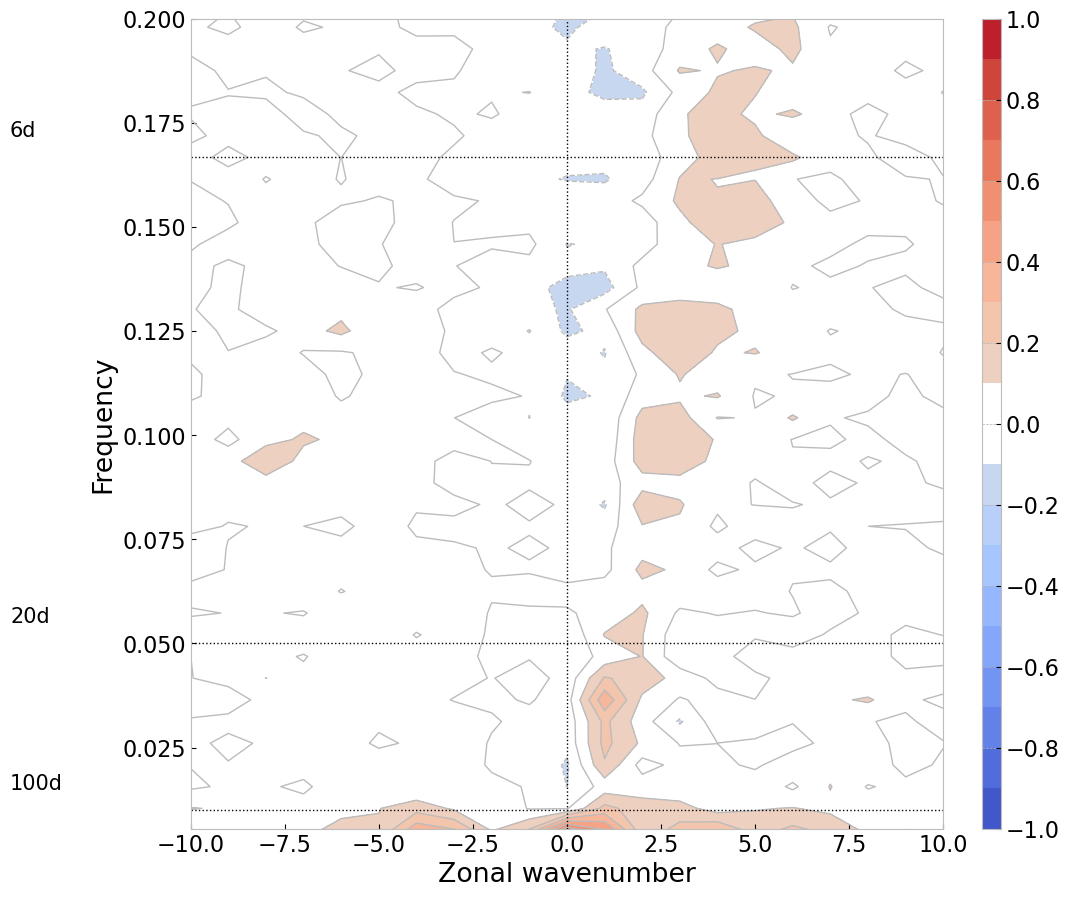

Finished


In [53]:
savefig = False

plt.style.use("bmh")
plt.rcParams.update({"font.size": 16})

variable_to_plot = 'PRECT'

fig = plt.figure(figsize=(9, 9))
gs = GridSpec(1, 2, width_ratios=[1, 0.025], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.1)

ax = fig.add_subplot(gs[0])
cbar_ax = fig.add_subplot(gs[1])

# ax.set_title(
#     + f" {symmetric_power_spectrum[variable_to_plot].attrs['longname']}"
#     + f"\n Symmetric Space-Time Power Spectrum",
#     pad=10
# )

im = ax.contourf(
    -zonal_wavenumber,
    frequency,
    # symmetric_power_spectrum[variable_to_plot],
    np.log10(symmetric_power_spectrum[variable_to_plot])[0],
    norm=mcolors.CenteredNorm(vcenter=0.0),
    cmap=mjo.modified_colormap("coolwarm", "white", 0.05, 0.05),
    # cmap='Spectral_r',
    # cmap='RdYlBu_r',
    # levels=np.linspace(-1, 1, 21),
    levels=np.arange(-1, 1.1, 0.1),
    # levels=np.linspace(-1.8, 0.8, 21),
    # levels=31,
    # extend='both'
)

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_ticks(
    # np.arange(-1.2, 0.91, 0.2)
    im.levels[::2]
)

im = ax.contour(
    -zonal_wavenumber,
    frequency,
    # symmetric_power_spectrum[variable_to_plot],
    np.log10(symmetric_power_spectrum[variable_to_plot])[0],
    # norm=mcolors.CenteredNorm(vcenter=0.0),
    # cmap=mjo.modified_colormap("coolwarm", "white", 0.05, 0.05),
    colors='#bcbcbc',
    # cmap='bwr',
    # cmap='Spectral_r',
    # cmap='RdYlBu_r',
    # levels=np.linspace(-1, 1, 21),
    # levels=np.arange(-1, 1.1, 0.1)[np.abs(np.arange(-1, 1.1, 0.1)) >= 0.09],
    # levels=np.linspace(-1.8, 0.8, 21),
    levels=31,
    # extend='both'
    linewidths=1
)

# Mark 3, 6, 20 day period:
plot_days = [6, 20, 100]
for day in plot_days:
    ax.axhline(y=1 / day, color="k", lw=1, ls=":")
    ax.text(-14.8, 1 / day + 0.005, str(day) + "d", fontsize=15)

# Mark zonal wavenumber == 0:
ax.axvline(x=0, color="k", lw=1, ls=":")
# ax.axvline(x=1, color="k", lw=1, ls=":")

ax.set_xlim(-10, 10)
ax.set_xlabel("Zonal wavenumber")
ax.set_ylim(1 / 180, 1 / 5)
ax.set_ylabel("Frequency")
# ax.set_aspect(20 / (1 / 2 - 1 / 180))
ax.grid(False)

if not savefig:
    plt.show()
else:
    save_string = (
        f"symmetric_{experiment_to_plot}"
      + f"_{variable_to_plot}"
      + f"_space-time-power-spectrum.png"
        )
    print(f"Saving plot as {save_string}")
    plt.savefig(
        f"{output_directory}/space-time-power-spectra/{save_string}",
        dpi=500,
        bbox_inches="tight",
    )

print(f"{'='*40}")
print("Finished")

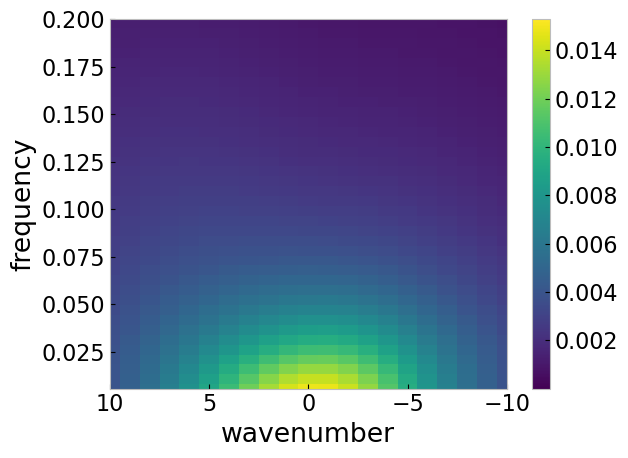

In [248]:
[fig, ax] = plt.subplots(1,1)
# symmetric_power_spectrum['PRECT'][0].plot(ax=ax, x='wavenumber')
background_spectrum['PRECT'].plot(ax=ax, x='wavenumber')
ax.set_xlim(-10,10)
ax.set_ylim(1/180,1/5)
ax.invert_xaxis()
plt.show()

## Regress Data

In [110]:
print(f"{'Regress Variables':^{str_width}}")
print(f"{'='*str_width}")

reference_indian_ocean_precipitation = variables_filtered['Precipitation'].sel(
    latitude=slice(-5,5),
    longitude=slice(85, 95)
).mean(dim=['latitude', 'longitude'])
tropical_precipitation = variables_filtered['Precipitation'].sel(
    latitude=slice(-10,10)
).mean(dim=['latitude'])

variables_regressed = {}
for index, (name, data) in enumerate(
    # {name:variables_subset[name] for name in ['Zonal Wind', 'Meridional Wind', 'Temperature', 'Precipitation']}.items()
    variables_subset.items()
):
    print(f'{f"({index+1}/{len(variables_subset)}) {name}...":<{str_width-1}}', end="")
    variables_regressed[name] = xr.dot(
        standardize_data(data, dim='time', unit_variance=False),
        standardize_data(reference_indian_ocean_precipitation, dim='time'),
        dim='time'
    ) / len(data.time)
    variables_regressed[name].attrs = data.attrs
    variables_regressed[name].to_netcdf(f"/glade/campaign/univ/uwas0152/CAMulator/regressed_data/regressed_warmed_{name.lower().replace(" ", "_")}.nc")
    print(rf"{'✔':>1}")

print(f"{'='*str_width}")
print("Finished")

           Regress Variables            
(1/5) Zonal Wind...                    ✔
(2/5) Meridional Wind...               ✔
(3/5) Temperature...                   ✔
(4/5) Specific Total Water...          ✔
(5/5) Precipitation...                 ✔
Finished


In [4]:
regressed_precipitation = xr.load_dataarray("/glade/campaign/univ/uwas0152/CAMulator/regressed_data/regressed_warmed_precipitation.nc")
regressed_temperature = xr.load_dataarray("/glade/campaign/univ/uwas0152/CAMulator/regressed_data/regressed_warmed_temperature.nc")
regressed_specific_water = xr.load_dataarray("/glade/campaign/univ/uwas0152/CAMulator/regressed_data/regressed_warmed_specific_total_water.nc")
regressed_zonal_wind = xr.load_dataarray("/glade/campaign/univ/uwas0152/CAMulator/regressed_data/regressed_warmed_zonal_wind.nc")
regressed_meridional_wind = xr.load_dataarray("/glade/campaign/univ/uwas0152/CAMulator/regressed_data/regressed_warmed_meridional_wind.nc")

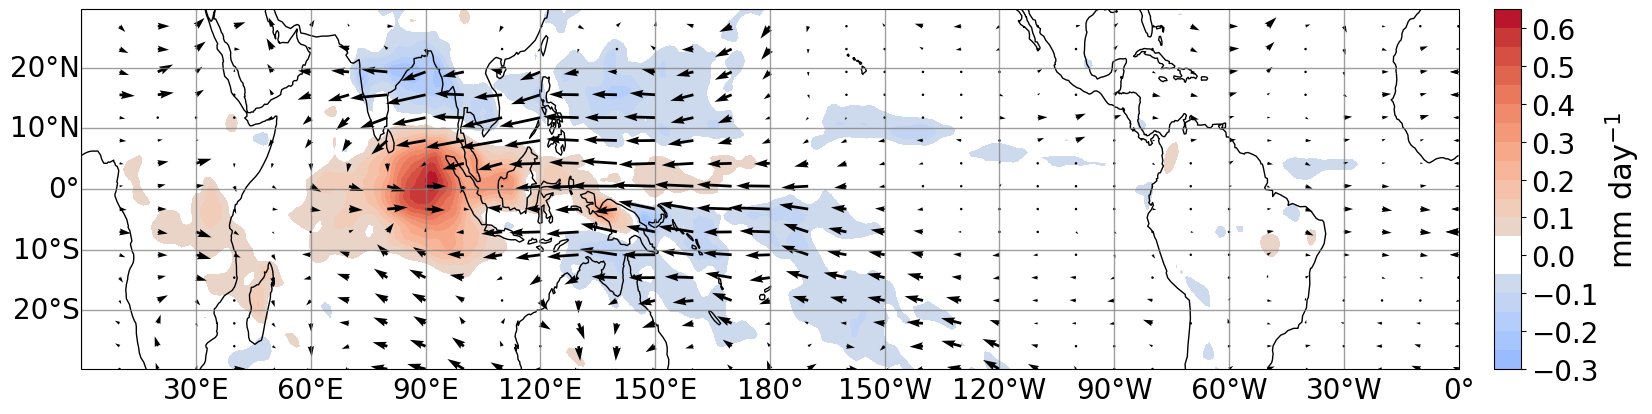

In [6]:
plt.rcParams.update({'font.size':22})
cmap_modified = modified_colormap('coolwarm', 'white', 0.05, 0.05)

gs = GridSpec(1, 2, width_ratios=(1, 0.02))
gs.update(top=.95, bottom=0.05, left=0.05, right=.95, hspace=0, wspace=0.05)
f = plt.figure(figsize=(16,4))

ax = f.add_subplot(gs[0], projection=ccrs.PlateCarree(central_longitude=-180))
cb_ax = f.add_subplot(gs[1])

plev_to_plot = 850
variable_to_plot = 'Precipitation'

variables_regressed = {}
variables_regressed['Precipitation'] = regressed_precipitation
variables_regressed['Temperature'] = regressed_temperature
variables_regressed['Specific Total Water'] = regressed_specific_water
variables_regressed['Zonal Wind'] = regressed_zonal_wind
variables_regressed['Meridional Wind'] = regressed_meridional_wind

# Moisture Tendency
# ax.set_title(f"Time-Mean Precipitation Anomalies and 850-hPa Zonal Winds", fontsize=20)

# Add cyclic point
cyclic_data = add_cyclic_xarray(variables_regressed[variable_to_plot])

im = ax.contourf(
    cyclic_data.longitude,
    variables_regressed[variable_to_plot].latitude,
    cyclic_data,
    transform=ccrs.PlateCarree(),
    cmap=cmap_modified,
    norm=mcolors.CenteredNorm(),
    levels=21
)
cbar = f.colorbar(im, cax=cb_ax)
cbar.ax.tick_params(labelsize=20)
# cbar.set_label(r'W m$^{-2}$')
cbar.set_label(r'mm day$^{-1}$')


cyclic_zonal_wind = add_cyclic_xarray(variables_regressed['Zonal Wind'])
cyclic_meridional_wind = add_cyclic_xarray(variables_regressed['Meridional Wind'])

arrow_spacing = 4
ax.quiver(
    cyclic_zonal_wind.longitude.values[::2*arrow_spacing],
    cyclic_zonal_wind.latitude.values[::arrow_spacing],
    cyclic_zonal_wind.sel(plev=plev_to_plot).values[::arrow_spacing, ::2*arrow_spacing],
    cyclic_meridional_wind.sel(plev=plev_to_plot).values[::arrow_spacing, ::2*arrow_spacing],
    width=0.002,
    scale=25,
    transform=ccrs.PlateCarree()
)

ax.set_aspect('auto')
ax.set_xlabel('')
ax.add_feature(cf.COASTLINE, lw=1)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=1,
    color="gray",
    alpha=0.75,
    linestyle="-",
    zorder=15

)
gl.right_labels = False
gl.top_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180,180,30))
# gl.xlocator = LongitudeLocator(30)
gl.xformatter = LongitudeFormatter()
gl.xlabel_style = {'fontsize':20}
gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
gl.yformatter = LatitudeFormatter()
gl.ylabel_style = {'fontsize':20}

plt.show()

In [7]:
zonal_wind_gradient = (
    (180/np.pi)
    * variables_regressed['Zonal Wind'].differentiate('longitude')
    / (EARTH_RADIUS*np.cos(np.deg2rad(variables_regressed['Zonal Wind'].latitude)))
)

meridional_wind_gradient = (
            (180/np.pi)
            * variables_regressed['Meridional Wind'].differentiate('latitude')
            / EARTH_RADIUS
        )

vertical_wind_gradient = -(zonal_wind_gradient + meridional_wind_gradient)

computed_vertical_wind = xr.zeros_like(variables_regressed['Zonal Wind'])
for p_index, plev in enumerate(variables_regressed['Zonal Wind'].plev):
    computed_vertical_wind[p_index] = 100*vertical_wind_gradient.sel(plev=slice(10, plev)).integrate('plev')

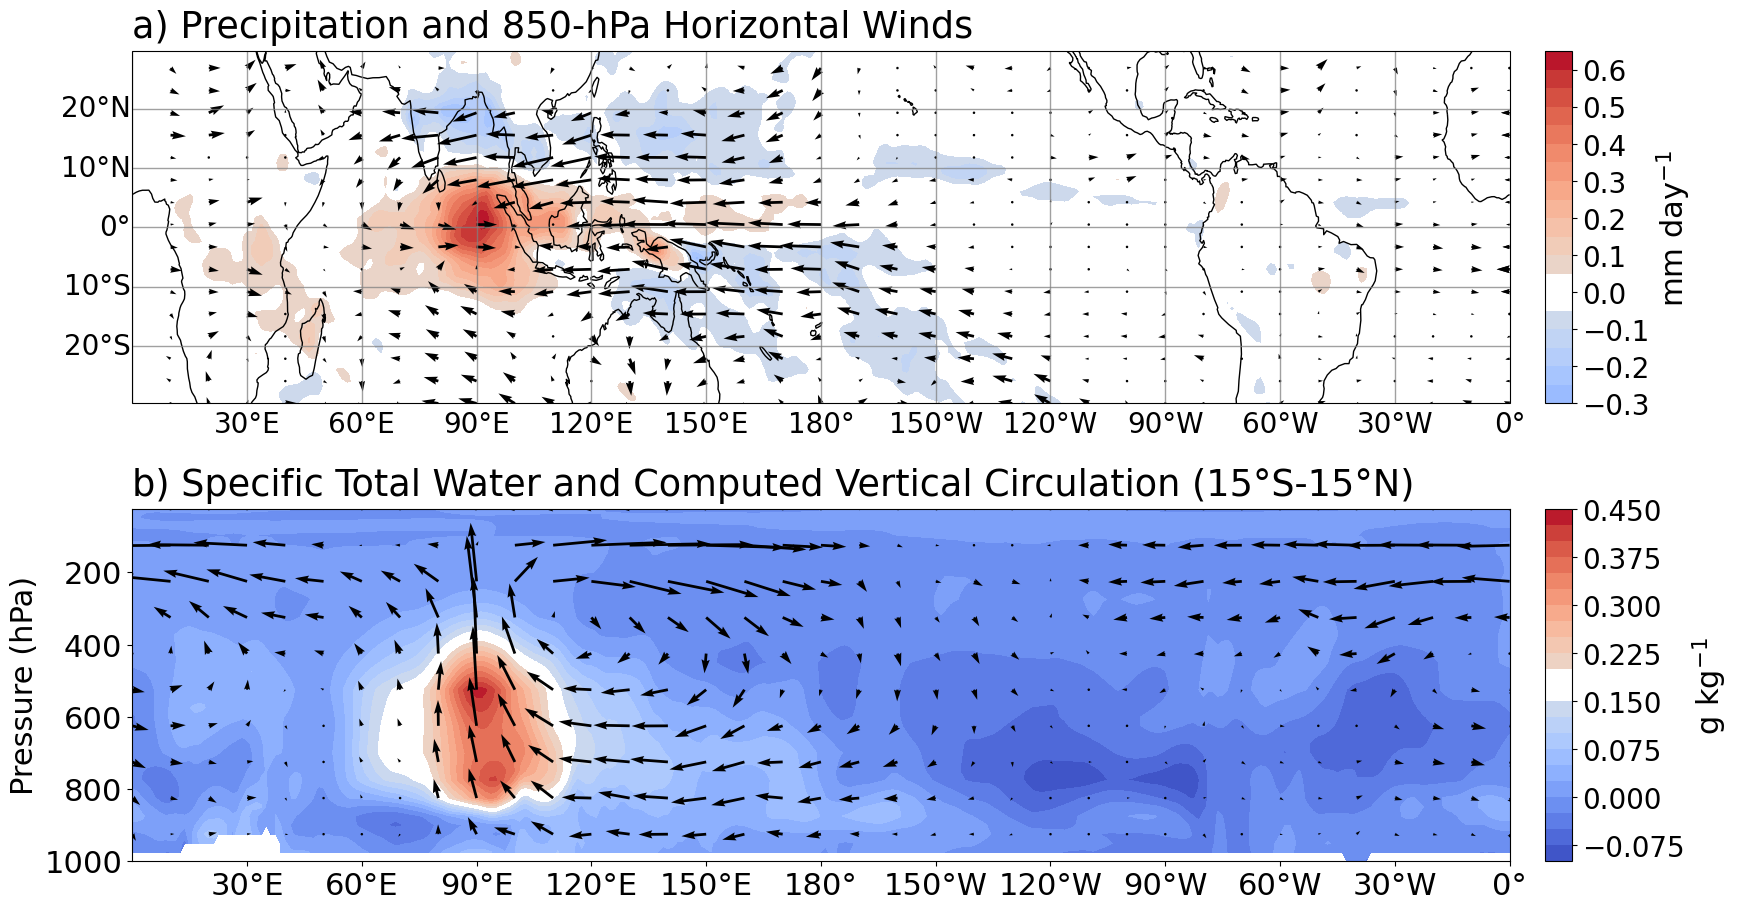

In [8]:
cmap_modified = modified_colormap('coolwarm', 'white', 0.05, 0.05)

plt.rcParams.update({'font.size':22})

gs = GridSpec(2, 2, width_ratios=(1, 0.02))
gs.update(top=.95, bottom=0.05, left=0.05, right=.95, hspace=0.3, wspace=0.05)
fig = plt.figure(figsize=(16,9))

axes = []
axes.append(fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree(central_longitude=-180)))
axes.append(fig.add_subplot(gs[1,0]))

cbar_axes = []
cbar_axes.append(fig.add_subplot(gs[0,1]))
cbar_axes.append(fig.add_subplot(gs[1,1]))

plev_to_plot = 850
latlon_variable_to_plot = 'Precipitation'
heightlon_variable_to_plot = 'Specific Total Water'

variables_regressed = {}
variables_regressed['Precipitation'] = regressed_precipitation
variables_regressed['Temperature'] = regressed_temperature
variables_regressed['Specific Total Water'] = regressed_specific_water
variables_regressed['Zonal Wind'] = regressed_zonal_wind
variables_regressed['Meridional Wind'] = regressed_meridional_wind

cyclic_latlon_data = add_cyclic_xarray(variables_regressed[latlon_variable_to_plot])
cyclic_heightlon_data = add_cyclic_xarray(variables_regressed[heightlon_variable_to_plot])
cyclic_zonal_wind = add_cyclic_xarray(variables_regressed['Zonal Wind'])
cyclic_meridional_wind = add_cyclic_xarray(variables_regressed['Meridional Wind'])
cyclic_vertical_wind = add_cyclic_xarray(computed_vertical_wind)

# Add cyclic point


axes[0].set_title(f"a) {latlon_variable_to_plot} and {plev_to_plot}-hPa Horizontal Winds", loc='left', pad=10)
im = axes[0].contourf(
    cyclic_latlon_data.longitude,
    cyclic_latlon_data.latitude,
    cyclic_latlon_data,
    transform=ccrs.PlateCarree(),
    cmap=cmap_modified,
    norm=mcolors.CenteredNorm(),
    levels=21
)
cbar = fig.colorbar(im, cax=cbar_axes[0])
cbar.ax.tick_params(labelsize=20)
# cbar.set_label(r'W m$^{-2}$')
# cbar.set_label(r'mm day$^{-1}$')
cbar.set_label(cyclic_data.attrs['units'])

arrow_spacing = 4
axes[0].quiver(
    cyclic_zonal_wind.longitude.values[::2*arrow_spacing],
    cyclic_zonal_wind.latitude.values[::arrow_spacing],
    cyclic_zonal_wind.sel(plev=plev_to_plot).values[::arrow_spacing, ::2*arrow_spacing],
    cyclic_meridional_wind.sel(plev=plev_to_plot).values[::arrow_spacing, ::2*arrow_spacing],
    width=0.002,
    scale=25,
    transform=ccrs.PlateCarree()
)

axes[0].set_aspect('auto')
axes[0].set_xlabel('')
axes[0].add_feature(cf.COASTLINE, lw=1)

gl = axes[0].gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=1,
    color="gray",
    alpha=0.75,
    linestyle="-",
    zorder=15
)
gl.right_labels = False
gl.top_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180,180,30))
# gl.xlocator = LongitudeLocator(30)
gl.xformatter = LongitudeFormatter()
gl.xlabel_style = {'fontsize':20}
gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
gl.yformatter = LatitudeFormatter()
gl.ylabel_style = {'fontsize':20}

#### Add longitude-height plot



axes[1].set_title(f"b) {heightlon_variable_to_plot} and Computed Vertical Circulation (15°S-15°N)", loc='left', pad=10)
im2 = axes[1].contourf(
    cyclic_heightlon_data.longitude,
    cyclic_heightlon_data.plev,
    1000*cyclic_heightlon_data.sel(latitude=slice(-10,10)).mean(dim='latitude'),
    # levels=im.levels,
    levels=21,
    cmap=cmap_modified
)

cbar = fig.colorbar(im2, cax=cbar_axes[1])
cbar.ax.tick_params(labelsize=20)
# cbar.set_label(r'W m$^{-2}$')
# cbar.set_label(r'mm day$^{-1}$')
# cbar.set_label(cyclic_data.attrs['units'])
cbar.set_label(r'g kg$^{-1}$')

arrow_spacing = 4
axes[1].quiver(
    cyclic_zonal_wind.longitude.values[::2*arrow_spacing],
    cyclic_zonal_wind.plev.values[::arrow_spacing],
    cyclic_zonal_wind.sel(latitude=slice(-15,15)).mean(dim='latitude').values[::arrow_spacing, ::2*arrow_spacing],
    -100*cyclic_vertical_wind.sel(latitude=slice(-15,15)).mean(dim='latitude').values[::arrow_spacing, ::2*arrow_spacing],
    width=0.002,
    scale=25,
)
axes[1].invert_yaxis()

axes[1].set_xticks(ticks=np.arange(0,360+30,30), labels=tick_labeller(np.arange(0,360+30,30), 'lon'))
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(nbins=13, prune="lower"))
axes[1].set_ylabel('Pressure (hPa)')

plt.show()

## Lag Regress Data

This follows the Maritime Continent propagation metric defined in Ahn et al. (2020) - https://doi.org/10.1029/2020GL087250

In [11]:
reference_indian_ocean_precipitation = variables_filtered['Precipitation'].sel(latitude=slice(-5,5), longitude=slice(85, 95)).mean(dim=['latitude', 'longitude'])
tropical_precipitation = variables_filtered['Precipitation'].sel(latitude=slice(-10,10)).mean(dim=['latitude'])

print(f"{'Lag Regressions':^{str_width}}")
# print(f"{f'Regression Variable: {regression_variable}':^{str_width}}")
print(f"{'='*str_width}")

# weights = np.cos(np.deg2rad(multi_experiment_variables_mjo_filtered['Precipitation'].lat))
# weights.name = "weights"
lag_days = np.arange(-25, 26)


lag_regression = xr.DataArray(
    data=np.empty((len(lag_days), len(tropical_precipitation.longitude))),
    dims=["lag", "longitude"],
    coords=dict(
        lag=lag_days,
        longitude=tropical_precipitation.longitude
    ),
    attrs = tropical_precipitation.attrs
)

for lag_index, lag in enumerate(lag_days):
    if (lag_index+1)%5 == 0:
        print(f"{f'({lag_index+1}/{len(lag_days)})...':<{str_width-1}}", end="")
    lag_regression[lag_index] = np.einsum(
            'i...,i...->...',
            standardize_data(tropical_precipitation, dim='time', unit_variance=True),
            np.roll(standardize_data(reference_indian_ocean_precipitation, dim='time', unit_variance=True), shift=lag),
        ) / len(reference_indian_ocean_precipitation.time)
    if (lag_index+1)%5 == 0:
        print(rf"{'✔':>1}")

print(f"{'='*str_width}")
print("Finished")

            Lag Regressions             
(5/51)...                              ✔
(10/51)...                             ✔
(15/51)...                             ✔
(20/51)...                             ✔
(25/51)...                             ✔
(30/51)...                             ✔
(35/51)...                             ✔
(40/51)...                             ✔
(45/51)...                             ✔
(50/51)...                             ✔
Finished


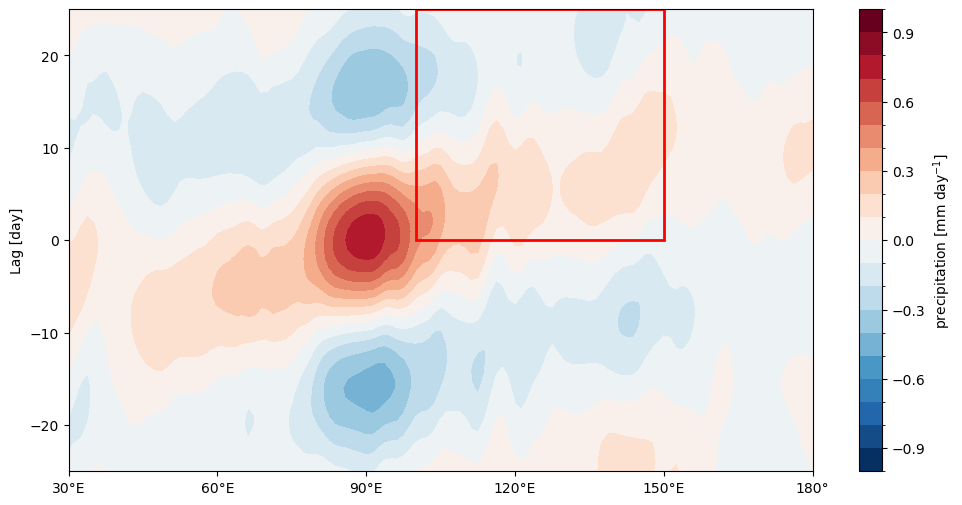

In [12]:
from matplotlib.patches import Rectangle
plt.style.use('default')
[fig, ax] = plt.subplots(1, 1, figsize=(12,6))
lag_regression.plot.contourf(ax=ax, x='longitude', levels=np.linspace(-1, 1, 21))
rect = Rectangle((100, 0), 50, 25, facecolor='none', edgecolor='red', linewidth=2)
ax.add_patch(rect)
ax.set_xlim(30, 180)
ax.set_yticks(np.arange(-20, 30, 10))
ax.set_ylabel('Lag [day]')
ax.set_xticks(np.arange(30, 180+30, 30), labels=(tick_labeller(np.arange(30, 180+30, 30), 'lon')))
ax.set_xlabel('')
ax.set_aspect('auto')
plt.show()